# Section A: Concept Application


1. You load the Amazon Reviews dataset and find reviews stored as plain text
strings. Why is text considered unstructured data compared to tabular data?

Text is considered unstructured data because it does not follow a predefined schema, format, or organization. Unlike tabular data, which is arranged in rows and columns with clearly defined attributes, text data consists of free-form sentences, phrases, and words that vary in length, grammar, and meaning.

For example, in the Amazon Reviews dataset:

"This laptop has excellent battery life and fast performance."

the review contains valuable information, but the product features, sentiment, and keywords are embedded within natural language. A computer cannot directly interpret these elements without preprocessing techniques such as tokenization, cleaning, and feature extraction.

| Structured (Tabular) Data        | Unstructured (Text) Data          |
| -------------------------------- | --------------------------------- |
| Fixed rows and columns           | No predefined format              |
| Easily stored in databases       | Requires NLP preprocessing        |
| Numerical and categorical values | Natural language sentences        |
| Directly analyzable              | Must be transformed into features |
| Consistent schema                | Variable length and vocabulary    |


2. You count unique words across all reviews to measure vocabulary size. What
is a corpus in NLP terminology?


In Natural Language Processing (NLP), a corpus is a collection of text documents that are used for linguistic analysis, text mining, and machine learning tasks.

For the Amazon Reviews dataset, the corpus consists of all customer reviews combined into a single body of text. Each individual review is considered a document, while the entire set of reviews forms the corpus.

Review 1: "Great battery life and excellent performance."

Review 2: "The screen quality is amazing."

Review 3: "Battery drains quickly."

When you count unique words across all reviews, you are analyzing the vocabulary of the corpus. For the example above, the vocabulary would include:

{
great, battery, life, and, excellent, performance,
the, screen, quality, is, amazing,
drains, quickly
}

Thus:

Document → One review.
Corpus → The complete collection of reviews.
Vocabulary → All unique words appearing in the corpus.
Corpus Size → Total number of tokens (words) in the corpus.

3. You print the top 20 most frequent words and find 'the', 'a', and 'is' dominate
the list. What does this tell you about the usefulness of the most frequent
words for sentiment analysis?

The fact that words such as "the", "a", and "is" dominate the top-frequency list indicates that the most common words in the corpus are primarily stop words rather than sentiment-bearing words.

Stop words are frequently occurring grammatical words that help form sentence structure but usually carry little semantic or emotional meaning. Therefore, they contribute very little to determining whether a review is positive or negative.
For example:

"The product is excellent."

The words "the" and "is" appear often across many reviews, but the word "excellent" is what conveys positive sentiment.

Implications for Sentiment Analysis
High-frequency words are not always informative.
Many of the most common words are stop words that add little predictive value.
Sentiment analysis models benefit from removing or down-weighting stop words.
More informative words include:
Positive: excellent, amazing, great, perfect
Negative: poor, terrible, disappointing, broken

4. The NLP pipeline follows a fixed sequence of stages. List the stages of a
standard NLP pipeline in order.

A standard NLP pipeline follows a sequence of stages that transform raw text into structured features suitable for analysis or machine learning.

Standard NLP Pipeline
Data Collection
Gather text data from sources such as reviews, social media, documents, or websites.
Text Cleaning / Preprocessing
Convert text to lowercase.
Remove punctuation, HTML tags, special characters, and extra spaces.
Handle missing or noisy data.
Tokenization
Split text into individual words, phrases, or sentences.
Stop-Word Removal
Remove common words such as the, a, is, and that carry little meaning.
Stemming or Lemmatization
Reduce words to their root form.
Example:
running → run
studies → study
Feature Extraction / Representation
Convert text into numerical features.
Common techniques:
Bag of Words (BoW)
TF-IDF
Word Embeddings (Word2Vec, GloVe, BERT)
NLP Analysis
Perform tasks such as:
N-gram Analysis
Sentiment Analysis
Topic Modeling
Named Entity Recognition (NER)
Model Building
Train machine learning or deep learning models using extracted features.
Evaluation
Measure performance using metrics such as accuracy, precision, recall, and F1-score.
Deployment / Reporting
Generate predictions, dashboards, reports, or production APIs.

Raw Text
    ↓
Text Cleaning
    ↓
Tokenization
    ↓
Stop-word Removal
    ↓
Stemming/Lemmatization
    ↓
Feature Extraction
    ↓
NLP Analysis / Modeling
    ↓
Evaluation
    ↓
Results & Insights

5. You identify URLs, emojis, and symbols scattered across the reviews. At which
stage of the NLP pipeline are these noisy patterns handled?

URLs, emojis, symbols, HTML tags, and other unwanted characters are typically handled during the Text Cleaning (Preprocessing) stage of the NLP pipeline.

Why?

These elements are often considered noise because they usually do not contribute meaningful information to tasks such as sentiment analysis, topic modeling, or text classification. Removing or normalizing them improves data quality and reduces vocabulary size.

| Raw Text                        | Noise Type        |
| ------------------------------- | ----------------- |
| `https://amazon.com/product123` | URL               |
| `😊🔥👍`                        | Emoji             |
| `@user #sale`                   | Mentions/Hashtags |
| `$%^&*`                         | Special Symbols   |
| `<html>Great Product</html>`    | HTML Tags         |


Raw Reviews
      ↓
Text Cleaning / Preprocessing
      ↓
Tokenization
      ↓
Stop-word Removal
      ↓
Feature Extraction

# Section B: Practical Task

1. Implement a custom regex-based tokenizer to isolate technical specifications
and currency symbols from raw text.

In [ ]:
import re

def custom_tokenizer(text):
    tech_pattern = r'\b\d+(?:\.\d+)?(?:GB|MB|TB|GHz|MHz|MP|mAh|inch|cm|mm|kg|g)\b'

    currency_pattern = r'[$₹€£]\s?\d+(?:,\d{3})*(?:\.\d+)?'

    tech_specs = re.findall(tech_pattern, text, re.IGNORECASE)
    currency_values = re.findall(currency_pattern, text)

    return {
        "technical_specs": tech_specs,
        "currency_values": currency_values
    }


text = """
Laptop with 16GB RAM, 512GB SSD, 3.2GHz processor.
Price: ₹55,999 or $699.
Battery: 5000mAh.
Camera: 108MP.
"""

result = custom_tokenizer(text)
print(result)

{'technical_specs': ['16GB', '512GB', '3.2GHz', '5000mAh', '108MP'], 'currency_values': ['₹55,999', '$699']}


2. Perform N-gram analysis (Bigram/Trigram) to identify recurring product
feature mentions in the Amazon corpus.

In [ ]:
import bz2
import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams

STOP_WORDS = set(stopwords.words("english"))

bigram_counts = Counter()
trigram_counts = Counter()

with bz2.open("train.ft.txt.bz2", "rt", encoding="utf-8") as f:

    for i, line in enumerate(f):

        text = line.split(" ", 1)[1].lower()

        tokens = re.findall(r"\b[a-z]+\b", text)
        tokens = [t for t in tokens if t not in STOP_WORDS]

        bigram_counts.update(ngrams(tokens, 2))
        trigram_counts.update(ngrams(tokens, 3))

        if i >= 100000:
            break

print("Top Bigrams:")
for bg, freq in bigram_counts.most_common(20):
    print(" ".join(bg), freq)

print("\nTop Trigrams:")
for tg, freq in trigram_counts.most_common(20):
    print(" ".join(tg), freq)

Top Bigrams:
read book 3711
one best 2155
waste money 1997
would recommend 1932
year old 1926
waste time 1755
much better 1718
great book 1606
years ago 1587
highly recommend 1460
first time 1429
good book 1354
book read 1338
reading book 1241
even though 1234
recommend book 1160
ever read 1157
blu ray 1152
great movie 1134
long time 1092

Top Trigrams:
book ever read 471
waste time money 399
would recommend book 317
recommend book anyone 311
books ever read 304
would recommend anyone 283
worst movie ever 268
movie ever seen 241
highly recommend book 238
one best books 237
would highly recommend 226
best book ever 216
worst book ever 204
year old son 197
year old daughter 182
movies ever seen 180
one worst movies 168
movie ever made 163
best books ever 156
many years ago 150


3. Execute a Zipf’s Law validation by plotting log-rank vs log-frequency to
analyze vocabulary distribution.

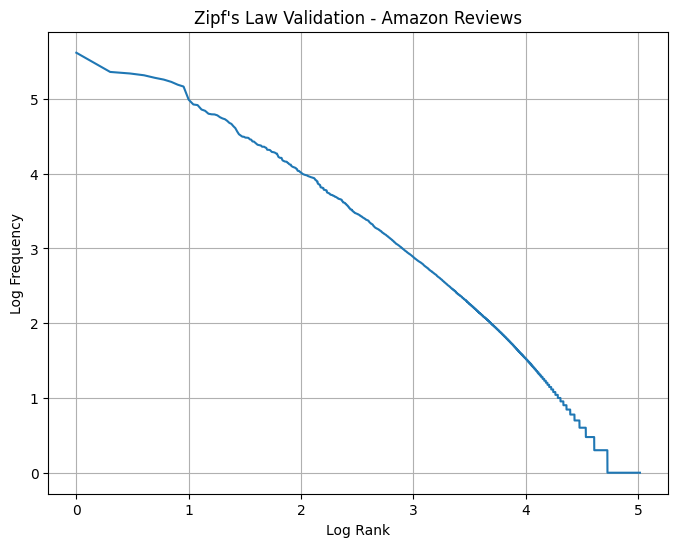

In [ ]:
import bz2
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

word_counts = Counter()

with bz2.open("train.ft.txt.bz2", "rt", encoding="utf-8") as f:

    for i, line in enumerate(f):

        text = line.split(" ", 1)[1].lower()

        words = re.findall(r'\b[a-z]+\b', text)

        word_counts.update(words)
        if i >= 100000:
            break

frequencies = sorted(word_counts.values(), reverse=True)

ranks = np.arange(1, len(frequencies) + 1)

log_ranks = np.log10(ranks)
log_freqs = np.log10(frequencies)

plt.figure(figsize=(8,6))
plt.plot(log_ranks, log_freqs)

plt.xlabel("Log Rank")
plt.ylabel("Log Frequency")
plt.title("Zipf's Law Validation - Amazon Reviews")
plt.grid(True)

plt.show()

4. Script a data-quality auditor to quantify the ratio of stop-words to informative
tokens across review categories.

In [ ]:
import bz2
import pandas as pd
import re
from collections import Counter
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return tokens

reviews = []
labels = []

with bz2.open("train.ft.txt.bz2", "rt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        if line.startswith("__label__"):
            parts = line.split(" ", 1)

            label = parts[0]
            review = parts[1] if len(parts) > 1 else ""

            labels.append(label)
            reviews.append(review)

df = pd.DataFrame({
    "category": labels,
    "review": reviews
})

print("Total Reviews:", len(df))

def audit_tokens(text):

    tokens = tokenize(text)

    total_tokens = len(tokens)

    stop_count = sum(1 for token in tokens if token in stop_words)

    informative_count = total_tokens - stop_count

    ratio = (
        stop_count / informative_count
        if informative_count > 0
        else 0
    )

    return pd.Series([
        total_tokens,
        stop_count,
        informative_count,
        ratio
    ])

df[
    [
        "total_tokens",
        "stop_words",
        "informative_tokens",
        "stopword_ratio"
    ]
] = df["review"].apply(audit_tokens)

summary = (
    df.groupby("category")
      .agg({
          "total_tokens":"mean",
          "stop_words":"mean",
          "informative_tokens":"mean",
          "stopword_ratio":"mean"
      })
      .round(3)
)

print("DATA QUALITY AUDIT ")
print(summary)

overall_stop = df["stop_words"].sum()
overall_info = df["informative_tokens"].sum()

overall_ratio = overall_stop / overall_info

print("\nOverall Stop Words:", overall_stop)
print("Overall Informative Tokens:", overall_info)
print("Overall Ratio:", round(overall_ratio,4))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total Reviews: 3600000


# Section C: Mini Project

### Title: Automated Feedback Structural Auditor

Problem Statement: Design a high-fidelity structural profiling pipeline to
detect data quality issues in massive, unstructured consumer datasets before
modeling.

Dataset Recommendation: Amazon Reviews
(https://www.kaggle.com/datasets/bittlingmayer/amazonreviews)

Required Deliverables: Statistical Profiling Notebook, Regex-based Cleaning Script, NLP Pipeline Architecture Diagram


In [1]:
import bz2
import re
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
reviews = [] 

file_path = "train.ft.txt.bz2"

with bz2.open(file_path, "rt", encoding="utf-8") as file:
    for i, line in enumerate(file): # Load first 50,000 reviews
        if i == 50000:
            break
        label, text = line.split(' ', 1)

        reviews.append([label, text])

df = pd.DataFrame(reviews, columns=["label", "review"])

print(df.head())
print("\nDataset Shape:", df.shape)

        label                                             review
0  __label__2  Stuning even for the non-gamer: This sound tra...
1  __label__2  The best soundtrack ever to anything.: I'm rea...
2  __label__2  Amazing!: This soundtrack is my favorite music...
3  __label__2  Excellent Soundtrack: I truly like this soundt...
4  __label__2  Remember, Pull Your Jaw Off The Floor After He...

Dataset Shape: (50000, 2)


In [ ]:
df["char_length"] = df["review"].apply(len) 
df["word_count"] = df["review"].apply(lambda x: len(x.split())) 
empty_reviews = (df["review"].str.strip() == "").sum()  
duplicate_reviews = df["review"].duplicated().sum()

print("Total Reviews:", len(df))
print("Empty Reviews:", empty_reviews)
print("Duplicate Reviews:", duplicate_reviews)

print("\nAverage Character Length:", df["char_length"].mean())
print("Average Word Count:", df["word_count"].mean())

Total Reviews: 50000
Empty Reviews: 0
Duplicate Reviews: 0

Average Character Length: 442.0161
Average Word Count: 80.17758


In [ ]:
def clean_text(text):


    text = text.lower() 
    text = re.sub(r'https?://\S+', ' ', text) 
    text = re.sub(r'<.*?>', ' ', text) 
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)#
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()  
    return text

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)
print(df[["review", "clean_review"]].head())

                                              review  \
0  Stuning even for the non-gamer: This sound tra...   
1  The best soundtrack ever to anything.: I'm rea...   
2  Amazing!: This soundtrack is my favorite music...   
3  Excellent Soundtrack: I truly like this soundt...   
4  Remember, Pull Your Jaw Off The Floor After He...   

                                        clean_review  
0  stuning even for the non gamer this sound trac...  
1  the best soundtrack ever to anything i m readi...  
2  amazing this soundtrack is my favorite music o...  
3  excellent soundtrack i truly like this soundtr...  
4  remember pull your jaw off the floor after hea...  


In [6]:
stop_words = set(stopwords.words('english'))

def tokenize_text(text):
    tokens = word_tokenize(text)
    return tokens
df["tokens"] = df["clean_review"].apply(tokenize_text)
print(df["tokens"].head())

0    [stuning, even, for, the, non, gamer, this, so...
1    [the, best, soundtrack, ever, to, anything, i,...
2    [amazing, this, soundtrack, is, my, favorite, ...
3    [excellent, soundtrack, i, truly, like, this, ...
4    [remember, pull, your, jaw, off, the, floor, a...
Name: tokens, dtype: object


In [ ]:
audit_df = pd.DataFrame([
    [
        len(t),
        sum(w in stop_words for w in t),
        len(t) - sum(w in stop_words for w in t), 
        sum(w in stop_words for w in t)/len(t) if len(t)>0 else 0,
        (len(t)-sum(w in stop_words for w in t))/len(t) if len(t)>0 else 0
    ]
    for t in df["tokens"]
], columns=[
    "total_tokens",
    "stopword_tokens",
    "informative_tokens",
    "stopword_ratio",
    "informative_ratio"
])

print(audit_df.head())

   total_tokens  stopword_tokens  informative_tokens  stopword_ratio  \
0            80               36                  44        0.450000   
1           102               56                  46        0.549020   
2           135               67                  68        0.496296   
3           122               47                  75        0.385246   
4            90               44                  46        0.488889   

   informative_ratio  
0           0.550000  
1           0.450980  
2           0.503704  
3           0.614754  
4           0.511111  


In [8]:
bigram_counter = Counter(
    bg
    for tokens in df["tokens"]
    for bg in ngrams(
        [t for t in tokens if t not in stop_words and len(t) > 2],2 # remove stopwords and remove short words
    )
)
for bg, count in bigram_counter.most_common(20):
    print(bg, ":", count)

('read', 'book') : 2035
('one', 'best') : 1072
('waste', 'money') : 1028
('year', 'old') : 1021
('would', 'recommend') : 990
('waste', 'time') : 908
('great', 'book') : 883
('much', 'better') : 819
('highly', 'recommend') : 772
('years', 'ago') : 769
('book', 'read') : 746
('first', 'time') : 719
('good', 'book') : 710
('reading', 'book') : 696
('ever', 'read') : 659
('recommend', 'book') : 613
('even', 'though') : 609
('great', 'movie') : 563
('long', 'time') : 536
('well', 'written') : 531


In [9]:
trigram_counter = Counter(
    tg
    for tokens in df["tokens"]
    for tg in ngrams(
        [t for t in tokens if t not in stop_words and len(t) > 2], 3
    )
)

for tg, count in trigram_counter.most_common(20):
    print(tg, ":", count)

('book', 'ever', 'read') : 281
('waste', 'time', 'money') : 206
('books', 'ever', 'read') : 175
('would', 'recommend', 'book') : 164
('recommend', 'book', 'anyone') : 157
('would', 'recommend', 'anyone') : 154
('worst', 'movie', 'ever') : 142
('one', 'best', 'books') : 137
('worst', 'book', 'ever') : 125
('best', 'book', 'ever') : 124
('highly', 'recommend', 'book') : 123
('year', 'old', 'son') : 116
('movie', 'ever', 'seen') : 116
('would', 'highly', 'recommend') : 110
('pampers', 'baby', 'dry') : 106
('best', 'books', 'ever') : 92
('one', 'worst', 'movies') : 88
('year', 'old', 'daughter') : 86
('movies', 'ever', 'seen') : 82
('movie', 'ever', 'made') : 78


In [10]:
def detect_issues(text):
    issues = []

    if re.search(r'https?://\S+', text): issues.append("URL")
    if re.search(r'\S+@\S+', text): issues.append("EMAIL")
    if re.search(r'<.*?>', text): issues.append("HTML")
    if len(text.split()) < 3: issues.append("TOO_SHORT")
    if len(text.split()) > 300: issues.append("TOO_LONG")

    return ", ".join(issues)

df["quality_issues"] = df["review"].apply(detect_issues)

print(df[["review", "quality_issues"]].head())

                                              review quality_issues
0  Stuning even for the non-gamer: This sound tra...               
1  The best soundtrack ever to anything.: I'm rea...               
2  Amazing!: This soundtrack is my favorite music...               
3  Excellent Soundtrack: I truly like this soundt...               
4  Remember, Pull Your Jaw Off The Floor After He...               


In [11]:
df.to_csv("cleaned_reviews.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
